<a href="https://colab.research.google.com/github/djaafarblb/homeWork/blob/main/static_files/assignments/hw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Devoir 3 &mdash; Images Panoramiques
**Échéance : 18 mars 2026**
<br><br>

## Récupération des fichiers dans Colab

In [8]:
#
# Exécutez cette cellule pour préparer votre environnement Colab.
#
%%capture
!wget https://benhadid.github.io/m1vpo/static_files/assignments/hw2.zip
!unzip hw2.zip
!mv hw2/* .
!rm -rf hw2
!rm -rf hw2.zip

## Initialisation du bloc-notes

In [9]:
from __future__ import print_function

# Setup
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 12) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# configurer Numpy pour afficher trois decimals après la virgule
#np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})
np.set_printoptions(precision=3)

# pour le rechargement automatique des modules externes
#load_ext autoreload
#autoreload

## données références pour validation des TODOs
loaded = np.load('./arrays.npz', allow_pickle=True)

## 1. Description

L'assemblage d'images en panorama est un très grand succès de la Vision Par Ordinateur. Matthew Brown et David G. Lowe ont publié un célèbre [article](https://drive.google.com/file/d/1qB54hR4TS_7But2KKkvuk6jTV1uWg8Tf/view?usp=sharing) sur cette technique en 2007. Depuis lors, cette technologie a été largement adoptée dans de nombreuses applications telles que "**Google Street View**" et les prises d'images panoramiques sur les smartphones.

Dans ce devoir, vous allez implémenter une solution pour combiner une série d'images se chevauchant en une seule image panoramique. La détection des points-clés dans les images et un appariement initial est déjà fourni dans le code de démarrage (usage de fonctions ORB de OpenCV).

Dans un premier temps, vous implémenterez le code qui calcule la matrice de transformation homographique entre deux images à partir de paires de correnspondance de points-clés. Ensuite, vous coderez une fonction pour séparer les bonnes correspondances (inliers) des mauvaises (outliers) selon le principe de l'algorithme [RANdom SAmple Consensus - RANSAC](https://en.wikipedia.org/wiki/Random_sample_consensus). Cela permetra l'alignement automatiquement des images de façpn robuste (positions relatives les unes par rapport aux autres ainsi que le calcul des zones de chevauchements de celles-ci). En troisième étape, afin d'appliquer les opérations de projections des images en un panorama, vous coderez l'algorithme de projection bilineaire inverse discuté en [cours](). Enfin, les images résultantes devraient être fusionnées en un seul panorama homogène (suppression des effets de bord dans l'image finale).

Pour résumer, les étapes requises pour créer un panorama sont enumérées ci-dessous. Celles que vous devez implémenter dans ce devoir sont indiquées en gras :

1. Extraire les primitives dans les images
2. Mise en correspondance des primitives
3. **Calcul de la matrice de transformation**
4. **Alignement des images à l'aide de RANSAC**
5. **Projection et interpolation des images**
4. **Fusion des images en une image panoramique**

## 2. Règles de codage

**<span style='color:Red'>
NE MODIFIEZ PAS LE CODE SQUELETTE EN DEHORS DES BLOCS TODO.<br>L'EVALUATEUR AUTOMATIQUE SERA TRES MECHANT AVEC VOUS SI VOUS LE FAITES !
</span>**

### 2.1. Résumé des fonctions potentiellement utiles (vous n'êtes pas obligé de les utiliser)  
- numpy.divide,
- numpy.eye,
- numpy.ndarray,
- numpy.dot,
- numpy.linalg.svd,
- numpy.linalg.lstsq,
- numpy.linalg.inv,
- numpy.meshgrid

### 2.2. Résumé des fonctions <span style='color:Red'>interdites</span>
- cv2.findHomography,
- cv2.perspectiveTransform,
- cv2.warpPerspective,
- cv2.remap,
- cv2.getAffineTransform,
- cv2.getPerspectiveTransform,
- cv2.invertAffineTransform,
- cv2.warpAffine,
- skimage.transform.ProjectiveTransform,
- skimage.measure.ransac,
- skimage.transform.SimilarityTransform,
- skimage.transform.AffineTransform,
- skimage.transform.FundamentalMatrixTransform,
- skimage.transform.warp,
- skimage.transform.warp_coords

Vous pouvez utiliser ces fonctions pour le débogage de votre code, mais la version finale ne doit en aucun cas les inclure faute d'avoir un zéro pour le devoir.


## 3. Préparation des données (détection des points-clés et appariemment initial)

Dans la cellule suivante, nous exécutons un algorithme de détéction de coins sur deux images, et récupérons les descripteurs associés à ces clés. Ensuite, nous effectuons une mise en correspondance entre les deux images et affichons l'ensemble des résultats.

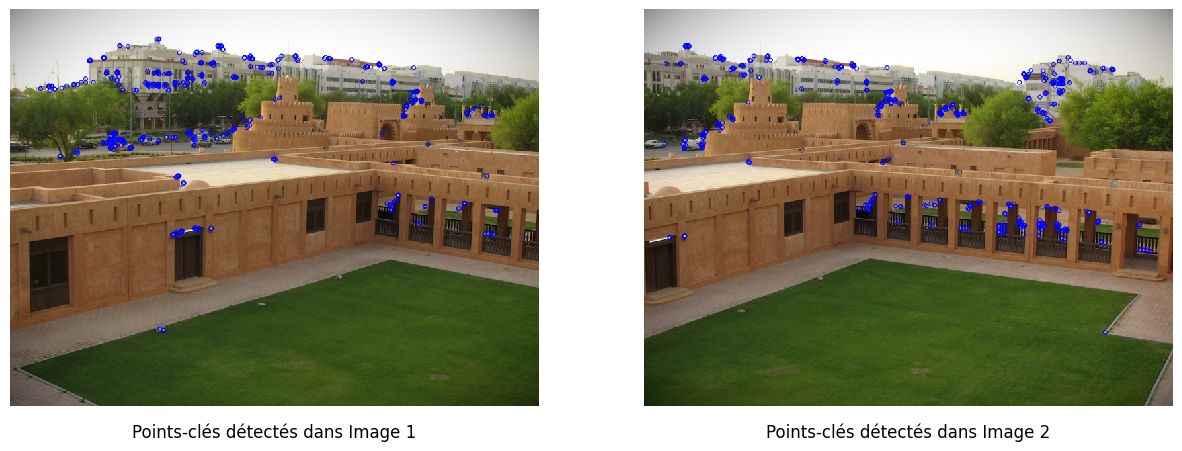

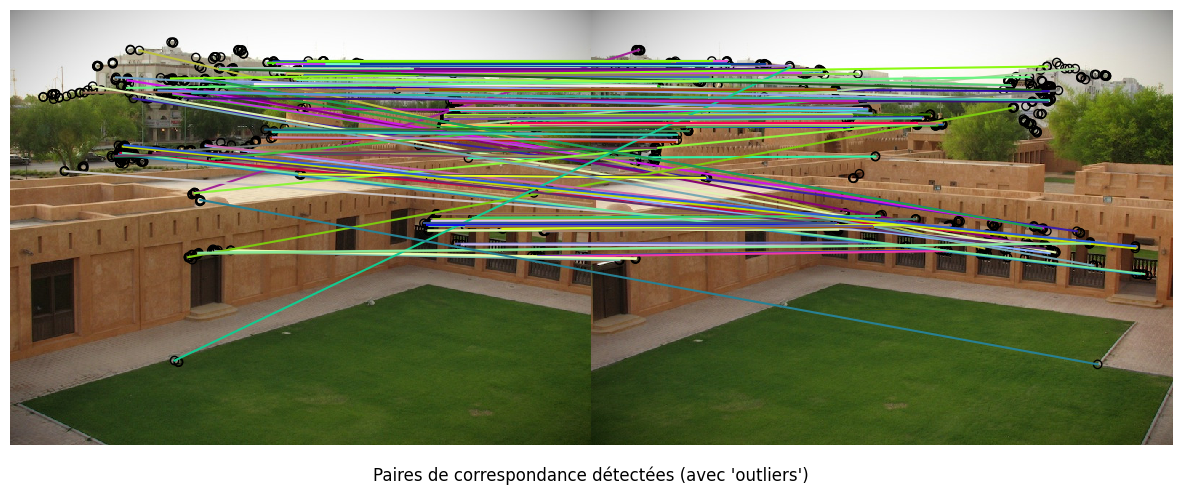

In [10]:
import cv2
from utils import plot_matches

# Commençant par charger deux images
img1 = cv2.imread('resources/al_ain/Image1.jpg')
img2 = cv2.imread('resources/al_ain/Image2.jpg')

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

imgs = [img1, img2]

# construisons l'objet orb pour la detection, description
orb = cv2.ORB_create()

# détection des points-clés et construction des
# descripteurs associés
keypoints_list   = []  # keypoints[i] corresponds to imgs[i]
descriptors_list = []  # descriptors[i] corresponds to keypoints[i]
for img in imgs:
    # trouver les points-clés et leurs descripteurs
    keypoints, descriptors = orb.detectAndCompute(img, None)

    keypoints_list.append(keypoints)
    descriptors_list.append(descriptors)

# construction de l'objet BFMatcher pour la mise en correspondance
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# matches_list[i] décrit la paire de correspondance entre les descripteurs descriptors[i] et descriptors[i+1]
matches_list = []
for pair in zip(descriptors_list[:-1], descriptors_list[1:]):
    matches = bf.match(pair[0], pair[1])
    matches_list.append(matches)

# Affichage des points-clés détectés pour les deux premières images
cvKeypoints1 = keypoints_list[0]
cvKeypoints2 = keypoints_list[1]

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(15, 12))

tmp = cv2.drawKeypoints(img1, cvKeypoints1, None, color=(0,0,255), flags=0)
ax1.imshow(tmp)
ax1.axis('off')
ax1.set_title('Points-clés détectés dans Image 1', y=-0.10)

tmp = cv2.drawKeypoints(img2, cvKeypoints2, None, color=(0,0,255), flags=0)
ax2.imshow(tmp)
ax2.axis('off')
ax2.set_title('Points-clés détectés dans Image 2', y=-0.10)
plt.show()

# traçons les correspondances...
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
ax.axis('off')

matches = np.array([ (m.queryIdx, m.trainIdx) for m in matches_list[0] ])

plot_matches(ax, img1, img2, cvKeypoints1, cvKeypoints2, matches,
                 keypoints_color='k', matches_color=None, only_matches=False)
plt.title('Paires de correspondance détectées (avec \'outliers\')', y=-0.10)
plt.show()

## 4. Les tâches

### 4.1. Estimation de la matrice de transformation [TODO 1] (10 points)

Nous avons maintenant une liste de points clés correspondants sur les deux images. Nous allons l'utiliser pour trouver une matrice de transformation qui mappe les points de la première image aux coordonnées correspondantes dans la deuxième image. En d'autres termes, si le point $p_1 = \left(x_1,y_1\right)$ dans l'image 1 correspond à $p_2=\left(x_2,y_2\right)$ dans l'image 2, nous devons trouver une matrice de transformation $\mathbf{H}$ telle que :

$$
\tilde{p_1}\mathbf{H}^T = \tilde{p_2},
$$

où $\tilde{p_1}$ et $\tilde{p_2}$ sont les coordonnées homogènes associées à $p_1$ et $p_2$.

Notez qu'il peut être impossible de trouver la transformation $\mathbf{H}$ qui mappe chaque point de l'image 1 **exactement** au point correspondant de l'image 2. Cependant, nous pouvons estimer la matrice de transformation avec les moindres carrés ou la décomposition en valeurs singulières. Étant donné $N$ paires de points-clés correspondants, soit $\mathbf{X_1}$ et $\mathbf{X_2}$ des matrices $ N \times 3 $ dont les lignes sont des coordonnées homogènes des points clés correspondants dans l'image 1 et l'image 2 respectivement. Nous pouvons estimer $\mathbf{H}$ en résolvant le problème des moindres carrés,

$$
\mathbf{X_1}\,\mathbf{H}^T = \mathbf{X_2}
$$

Dans la fonction **`fit_transform_matrix()`** du fichier` panorama.py`, implémentez le code pour estimer la matrice de transformation $\mathbf{H}$ à partir des coordonnées des points-clés appariés $p_1$ et $p_2$.

- **Indication** : Consultez les slides n° 12 et 40 du cours "[alignement des images](https://benhadid.github.io/m1vpo/lectures/)".

In [11]:
def fit_transform_matrix(p0, p1):
    """ Calcul la matrice de transformation H tel que p0 * H.T = p1

    Indication importante :
        Vous pouvez utiliser la fonction "np.linalg.lstsq" ou
        la fonction "np.linalg.svd" pour résoudre le problème.

    Entrées :
        p0 : un tableau numpy de dimension (M, 2) contenant
             les coordonnées des points à transformer
        p1 : un tableau numpy de dimension (M, 2) contenant
             les coordonnées des points destination

             Chaque coordonnée [x,y] dans p0 ou p1 indique
             la position d'un point-clé [col, ligne] dans
             l'image associée. C-à-d.  p0[i,:] = [x_i, y_i]
             et  p1[j,:] = [x'_j, y'_j]

    Sortie :
        H  : Tableau numpy de dimension (3,3) représentant la
             matrice de transformation d'homographie.
    """

    assert (p1.shape[0] == p0.shape[0]),\
        'Nombre différent de points en p1 et p2'

    H = None

    #TODO 1 : Calculez la matrice de transformation H.
    # TODO-BLOC-DEBUT
    M = p0.shape[0]
    X0 = np.hstack([p0, np.ones((M, 1))])
    X1 = np.hstack([p1, np.ones((M, 1))])

    HT, residuals, rank, s = np.linalg.lstsq(X0, X1, rcond=None)

    H = HT.T
    # TODO-BLOC-FIN

    return H




#
# testq de validité pour fit_transform_matrix()
#

# première image -- coordonnées organisées en ( y , x )
p0 = np.array([[0.0, 0.0],       # coin supérieur gauche
               [0.0, 1.0],       # coin supérieur droit
               [1.0, 0.0],       # coin inférieur gauche
               [1.0, 1.0]])      # coin inférieur droit

# deuxième image (première image pivotée de 45°)
v  = np.sqrt(2)/2.
p1 = np.array([[ 0.0, 0.0],
               [   v,   v],
               [   v,  -v],
               [ v+v, 0.0]])

#troisième image (première image agrandie deux fois horizontalement)
p2 = np.array([[ 0.0, 0.0],
               [ 0.0, 2.0],
               [ 1.0, 0.0],
               [ 1.0, 2.0]])

#quatrième image (première image projetée par Homographie)
p3 = np.array([[ 4.3,   7.3],
               [ 8.2,   7.2],
               [ 4.6,  10.7],
               [ 9.2,   9.2]])

# premier test
H1 = fit_transform_matrix(p0[:,[1,0]], p0[:,[1,0]])    #( [:, [1,0] ] <-> permutation des colonnes y et x)
H1 = H1 / H1[2,2]

# sortie attendue : la matrice identité
sol1 = np.eye(3)

#second test
H2 = fit_transform_matrix(p0[:,[1,0]], p1[:,[1,0]])
H2 = H2 / H2[2,2]

# sortie attendue : matrice de rotation (45°)
sol2 = np.array([[ v, -v, 0],
                 [ v,  v, 0],
                 [ 0,  0, 1]])

#troisième test
H3 = fit_transform_matrix(p0[:,[1,0]], p2[:,[1,0]])
H3 = H3 / H3[2,2]

# sortie attendue : matrice de changement d’échelle np.diag(2, 1, 1)
sol3 = np.array([[ 2.0,  0.0, 0],
                 [ 0.0,  1.0, 0],
                 [ 0.0,  0.0, 1]])

#quatrième test
H4 = fit_transform_matrix(p0[:,[1,0]], p3[:,[1,0]])
H4 = H4 / H4[2,2]

# sortie attendue : matrice Homographie standard (non-affine)
sol4 = np.array([[ 3.52692,  0.6,      7.3    ],
                 [ 8.03065, -0.90374,  4.3    ],
                 [ 0.50374, -0.26168,  1.     ]])

# comparaison des résultats
if  np.allclose(sol1, H1, rtol=1e-05, atol=1e-05):
    print('test identité   :  correct ! ')
else:
    print('test identité   :  incorrect !\nH = %s, \n\nsol = %s\n' % (H1,sol1))

if  np.allclose(sol2, H2, rtol=1e-05, atol=1e-05):
    print('test rotation   :  correct ! ')
else:
    print('test rotation   :  incorrect !\nH = %s, \n\nsol = %s\n' % (H2,sol2))

if  np.allclose(sol3, H3, rtol=1e-05, atol=1e-05):
    print('test échelle    :  correct ! ')
else:
    print('test échelle    :  incorrect !\nH = %s, \n\nsol = %s\n' % (H3,sol3))

if  np.allclose(sol4, H4, rtol=1e-05, atol=1e-05):
    print('test projection :  correct ! ')
else:
    print('test projection :  incorrect !\nH = %s, \n\nsol = %s\n' % (H4,sol4))

test identité   :  correct ! 
test rotation   :  correct ! 
test échelle    :  correct ! 
test projection :  incorrect !
H = [[-8.000e-01  2.700e+00  7.650e+00]
 [ 4.250e+00  6.500e-01  4.125e+00]
 [-9.231e-18  1.110e-16  1.000e+00]], 

sol = [[ 3.527  0.6    7.3  ]
 [ 8.031 -0.904  4.3  ]
 [ 0.504 -0.262  1.   ]]



### 4.2. Alignement des images à l'aide de RANSAC [TODO 2] (20 points)
Au lieu d'utiliser directement toutes nos correspondances de points-clés comme entrée pour la fonction `fit _transform_ matrix()`, il est préférable de sélectionner uniquement les points-clés valides (c.-à-d. les 'inliers') pour calculer la matrice de transformation $\mathbf{H}$. Nous utiliserons l'algorithme RANSAC ([RANdom SAmple Consensus](https://en.wikipedia.org/wiki/Random_sample_consensus)) pour cette tâche. Cet algorithme est modelé selon une approche probabiliste qui permet de classer les correnspondances entre points-clés en deux catégories : Les bonnes correspondances (inliers), et les mauvaises correspondances (outliers). Les étapes dans RANSAC sont énumérés comme suit :
1. Sélectionner, d'une manière aléatoire, un sous-ensemble de points-clés (c.-à-d. quatre paires) dans l'ensemble des correspondances $C$.   
2. Calculer une matrice de transformation $\hat{\mathbf{H}}$ à partir du sous-ensemble sélectionné.
3. Appliquer la matrice $\hat{\mathbf{H}}$ à l'ensemble complémentaire $\bar{C}$ et determiner les bonnes correspondances (inliers) selon un seuil prédéfini.
4. Répéter les étapes 1&ndash;3 plusieurs fois et conserver la matrice  $\hat{\mathbf{H}}$ qui produit le plus grand nombre de bonnes correspondances avec une confidence $\geq 99.9\%$.
5. Recalculer une meilleure estimation de la matrice $\hat{\mathbf{H}}$ en utilisant que les paires de points-clés classées comme &laquo; bonnes correspondances &raquo; (c.-à-d. les 'inliers').

Implémentez la fonction **`ransac()`** dans` panorama.py`. Puis, exécutez le code suivant pour validation.

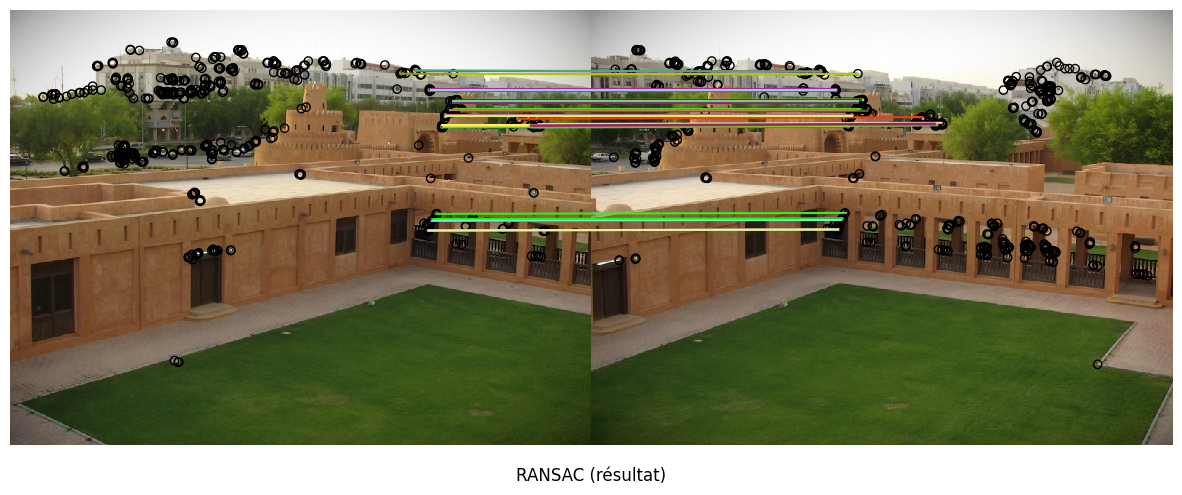

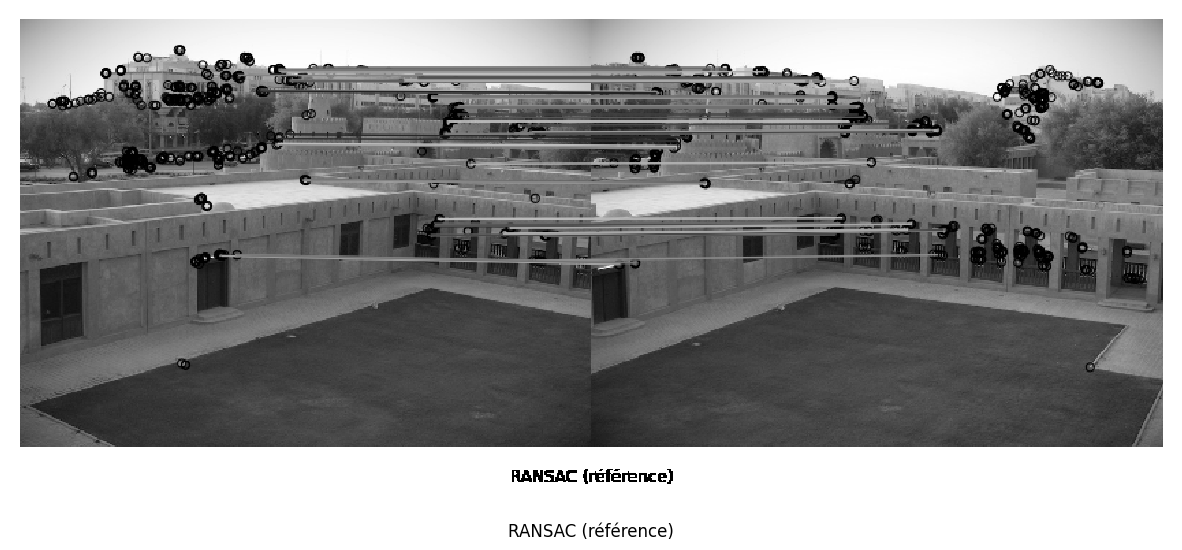

In [12]:
import random

def ransac(keypoints1, keypoints2, matches, n_iters=500, threshold=1):
    """
    Utilisez RANSAC pour trouver une transformation projective robuste

        1. Sélectionnez un ensemble aléatoire de correspondances
        2. Calculez la matrice de transformation H
        3. Calculez les bonnes correspondances (inliers)
        4. Gardez le plus grand ensemble de bonnes correspondances
        5. En final, recalculez la matrice de transformation H sur
           tout l'ensemble des bonnes correspondances

    Entrées :
        keypoints1 -- matrice M1 x 2, chaque rangée contient les coordonnées
                      d'un point-clé (x_i,y_i) dans image1
        keypoints2 -- matrice M2 x 2, chaque rangée contient les coordonnées
                      d'un point-clé (x'_i,y'_i) dans image2
        matches  -- matrice N x 2, chaque rangée représente une correspondance
                    [indice_dans_keypoints1, indice_dans_keypoints2]
        n_iters -- le nombre d'itérations à effectuer pour RANSAC
        threshold -- le seuil pour sélectionner des bonnes correspondances

    Sorties :
        H -- une estimation robuste de la matrice de transformation H
        matches[max_inliers] -- matrice (max_inliers x 2) des bonnes correspondances
    """
    # indices des bonnes correspondances dans le tableau 'matches'
    max_inliers = []

    # matrice de transformation Homographique
    H = None

    # Initialisation du générateur de nombres aléatoires
    # fixé le seed pour pouvoir comparer le résultat retourné par
    # cette fonction par rapport à la solution référence
    random.seed(131)

    #TODO 2 : Implémentez ici la méthode RANSAC pour trouver une transformation robuste
    # entre deux images image1 et image2.
    # TODO-BLOC-DEBUT

    p1_all = keypoints1[matches[:, 0]]
    p2_all = keypoints2[matches[:, 1]]

    num_matches = matches.shape[0]

    for i in range(n_iters):
        # Étape 1 : Sélectionner 4 paires de points de façon aléatoire
        indices = random.sample(range(num_matches), 4)
        sample_p1 = p1_all[indices]
        sample_p2 = p2_all[indices]

        # Étape 2 : Calculer la matrice H candidate (on utilise le TODO 1)
        H_candidate = fit_transform_matrix(sample_p1, sample_p2)

        # Étape 3 : Calculer les inliers pour cette matrice
        # On transforme tous les points p1 : p2_pred = p1_all * H_candidate.T
        # On passe en coordonnées homogènes pour la multiplication
        p1_all_homo = np.hstack([p1_all, np.ones((num_matches, 1))])
        p2_pred_homo = p1_all_homo @ H_candidate.T

        # Normalisation (si le dernier élément n'est pas 1, utile pour perspective)
        # Note : Si fit_transform_matrix est affine, p2_pred_homo[:, 2] sera déjà 1
        p2_pred = p2_pred_homo[:, :2] / p2_pred_homo[:, 2:].reshape(-1, 1)

        # Calculer la distance Euclidienne entre points réels et prédits
        distances = np.linalg.norm(p2_all - p2_pred, axis=1)

        # Trouver les indices où la distance est inférieure au seuil
        current_inlier_indices = np.where(distances < threshold)[0]

        # Étape 4 : Conserver le plus grand ensemble d'inliers
        if len(current_inlier_indices) > len(max_inliers):
            max_inliers = current_inlier_indices
    if len(max_inliers) > 0:
        H = fit_transform_matrix(p1_all[max_inliers], p2_all[max_inliers])

    # TODO-BLOC-FIN

    return H, matches[max_inliers]




# récupérer les coordonnées des points clés depuis les structures opencv
keypoints1 = np.squeeze( np.array( [  kp.pt  for kp in cvKeypoints1 ] ) )
keypoints2 = np.squeeze( np.array( [  kp.pt  for kp in cvKeypoints2 ] ) )

# lancer RANSAC
H, robust_matches = ransac(keypoints1, keypoints2, matches)

# Visualisation des correspondances robustes retournées par RANSAC
_, ax = plt.subplots(1, 1, figsize=(15, 12))
plot_matches(ax, img1, img2, cvKeypoints1, cvKeypoints2, robust_matches)
plt.axis('off')
plt.title('RANSAC (résultat)', y=-0.10)
plt.show()

plt.subplots(1, 1, figsize=(15, 12))
plt.imshow(cv2.cvtColor(cv2.imread('ransac.png'), cv2.COLOR_BGR2GRAY))
plt.axis('off')
plt.title('RANSAC (référence)', y=-0.10)
plt.show()

### 4.3. Projection inverse des images et interpolation bilineaire [TODO3] (40 points)

Nous pouvons maintenant utiliser la matrice de transformation $\mathbf{H}$ calculée à l'aide de RANSAC pour transformer nos images et créer un panorama ! En ce sens, nous avons besoin d'implémenter une méthode qui projette les coordonnées de chaque pixel dans l'image source vers les coordonnées transformées dans l'image destination.

Dans ce devoir, la fonction **`warp_image()`** dans `panorama.py` doit réaliser l'étape de "projection inverse avec interpolation bilinéaire" présentée dans le cours "[Images panoramiques](https://benhadid.github.io/m1vpo/lectures/)". C-à-d. Pour transformer les pixels de l'image source, nous commencerons à partir des coordonnées de l'image destination et nous utiliserons l'interpolation bilinéaire dans l'image source pour calculer les couleurs des pixels à reproduire dans l'image destination.

Une fois la fonction **`warp_image()`** implémentée, exécutez le code ci-dessous pour effectuer l'étape de projection.

**Indications :**
- Lorsque vous manipulez des coordonnées homogènes, n'oubliez pas de les normaliser avant de les reconvertir en coordonnées cartésiennes.
- Attention aux points en dehors de l'image source lors de la projection inverse. Ils ne doivent pas être inclus dans les calculs de l'image cible.
- Commencez par travailler sur le code en bouclant sur chaque pixel d'une manière itérative (approche classique). Ensuite, vous pouvez optimiser votre code en utilisant des instructions Numpy/Scipy (pensez à utiliser `numpy.meshgrid`).


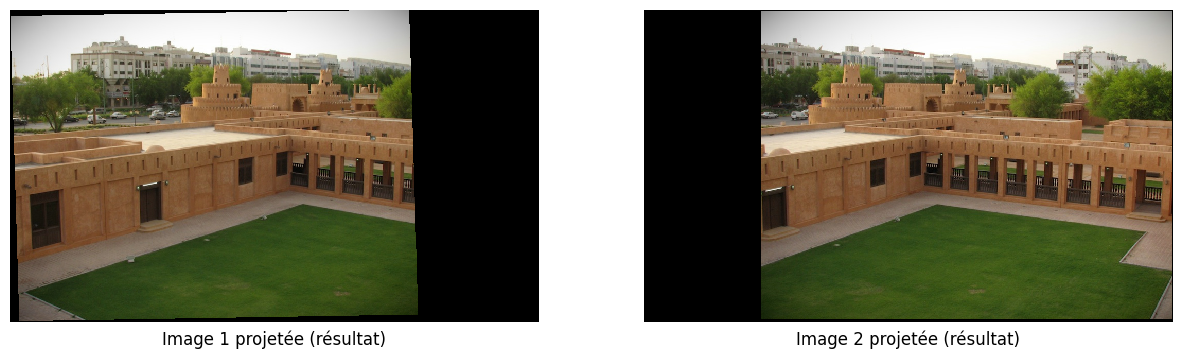

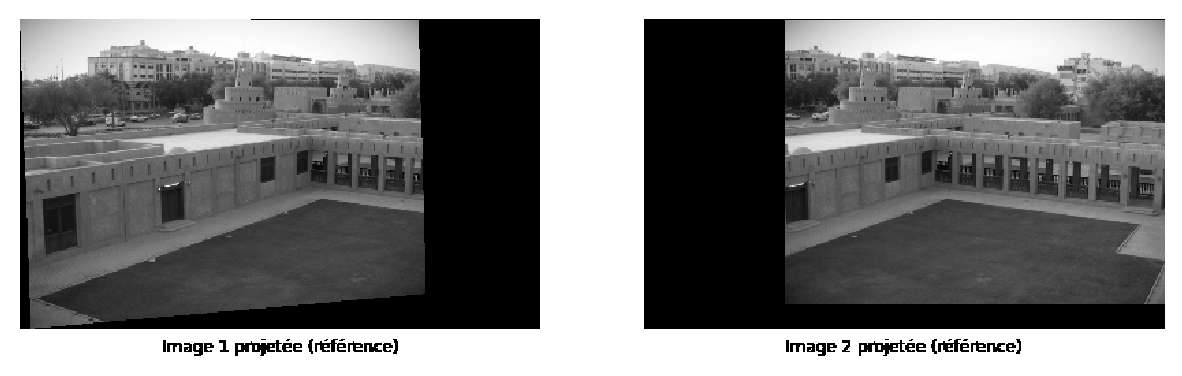

In [14]:

import numpy as np

from panorama import get_output_space



def warp_image(img, H, output_shape, offset, method=None):
    # Dimensions de l'image de sortie (H, W)
    out_h, out_w = output_shape[1], output_shape[0]
    img_warped = np.zeros((out_h, out_w, 3), dtype=np.float32)
    mask = np.zeros((out_h, out_w), dtype=bool)

    # Image source normalisée entre 0 et 1
    src = img.astype(np.float32) / 255.0
    src_h, src_w = src.shape[:2]

    # Matrice de transformation inverse
    H_inv = np.linalg.inv(H)

    # 1. Créer une grille de coordonnées pour l'image de destination
    # meshgrid crée des matrices de coordonnées x et y pour chaque pixel
    xx, yy = np.meshgrid(np.arange(out_w), np.arange(out_h))

    # 2. Appliquer l'offset et préparer les coordonnées homogènes (x, y, 1)
    # On déplace les coordonnées pour qu'elles correspondent au repère du panorama
    dst_coords = np.stack([xx.ravel() + offset[0], yy.ravel() + offset[1], np.ones(xx.size)])

    # 3. Projection inverse : src_coords = H_inv @ dst_coords
    src_coords_homo = H_inv @ dst_coords

    # Normalisation pour revenir en coordonnées cartésiennes
    src_x = src_coords_homo[0, :] / src_coords_homo[2, :]
    src_y = src_coords_homo[1, :] / src_coords_homo[2, :]

    # 4. Trouver les pixels valides (ceux qui "tombent" à l'intérieur de l'image source)
    # On garde une marge de 1 pour l'interpolation bilinéaire (x+1, y+1)
    valid_mask = (src_x >= 0) & (src_x < src_w - 1) & (src_y >= 0) & (src_y < src_h - 1)

    # On ne travaille que sur les points valides pour gagner en performance
    src_x_v = src_x[valid_mask]
    src_y_v = src_y[valid_mask]

    # 5. Interpolation Bilinéaire
    # Coordonnées entières des 4 voisins
    x0 = np.floor(src_x_v).astype(int)
    x1 = x0 + 1
    y0 = np.floor(src_y_v).astype(int)
    y1 = y0 + 1

    # Poids (distances fractionnaires)
    wa = (x1 - src_x_v) * (y1 - src_y_v)
    wb = (x1 - src_x_v) * (src_y_v - y0)
    wc = (src_x_v - x0) * (y1 - src_y_v)
    wd = (src_x_v - x0) * (src_y_v - y0)

    # Application des poids sur les 3 canaux (RGB)
    # reshape(-1, 1) permet de multiplier chaque canal par le même poids
    val = (src[y0, x0] * wa.reshape(-1, 1) +
           src[y1, x0] * wb.reshape(-1, 1) +
           src[y0, x1] * wc.reshape(-1, 1) +
           src[y1, x1] * wd.reshape(-1, 1))

    # Remplir l'image de sortie et le masque
    img_warped[yy.ravel()[valid_mask], xx.ravel()[valid_mask]] = val
    mask[yy.ravel()[valid_mask], xx.ravel()[valid_mask]] = True

    # TODO 5 : Alpha blending (Partie simplifiée pour l'instant)
    # Si method est None, alpha est déjà géré par le masque
    # Si method == 'linear', vous devrez calculer une rampe de 0 à 1

    return img_warped, mask



#left on right
transforms = [H , np.eye(3) ]

#right on left
#transforms = [np.eye(3), np.linalg.inv(H)  ]

# 'get_output_space' est une fonction auxiliaire qui aide
# à trouver le cadre global associé à une liste d'images transformées
output_shape, offset = get_output_space(imgs, transforms)

# transformation des images
img1_warped, _ = warp_image(imgs[0], transforms[0], output_shape, offset)
img2_warped, _ = warp_image(imgs[1], transforms[1], output_shape, offset)

# Visualisation des images transformées
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(15, 12))
ax1.imshow(img1_warped[:,:,:3])
ax1.axis('off')
ax1.set_title('Image 1 projetée (résultat)',y=-0.10)

ax2.imshow(img2_warped[:,:,:3])
ax2.axis('off')
ax2.set_title('Image 2 projetée (résultat)',y=-0.10)
plt.show()

plt.subplots(1, 1, figsize=(15, 12))
plt.imshow(cv2.cvtColor(cv2.imread('warped.png'), cv2.COLOR_BGR2GRAY))
plt.axis('off')
plt.show()

### 4.4. Assemblage (naïve) des images [TODO 4] (5 points)

Une fois les images transformées, il reste à les assembler en une seule image panoramique. Une méthode simple (et naïve) est d'additionner les deux images. Ainsi, pour chaque pixel $\left[i,j\right]$ dans l'image de destination, nous avons :

$$
dst[i,j] = \left(src_1\left[i,j\right] + src_2\left[i,j\right]\right) \bigg/ \sum_{k=1}^{2} alpha_k\left[i,j\right]
$$

où
- $src_1[i,j]$ et $src_2[i,j]$ sont respectivement les couleurs des pixels dans les images $src_1$ et $src_2$.
- $alpha_1$ et $alpha_2$ sont les canaux de transparence associés à ces images.

Implémentez la fonction **``naive_fusion()``** dans `panorama.py` puis exécutez le code suivant pour validation. Le panorama obtenu présentera sans doute des artéfacts de bords, mais nous verrons plus tard comment obtenir un meilleur résultat.

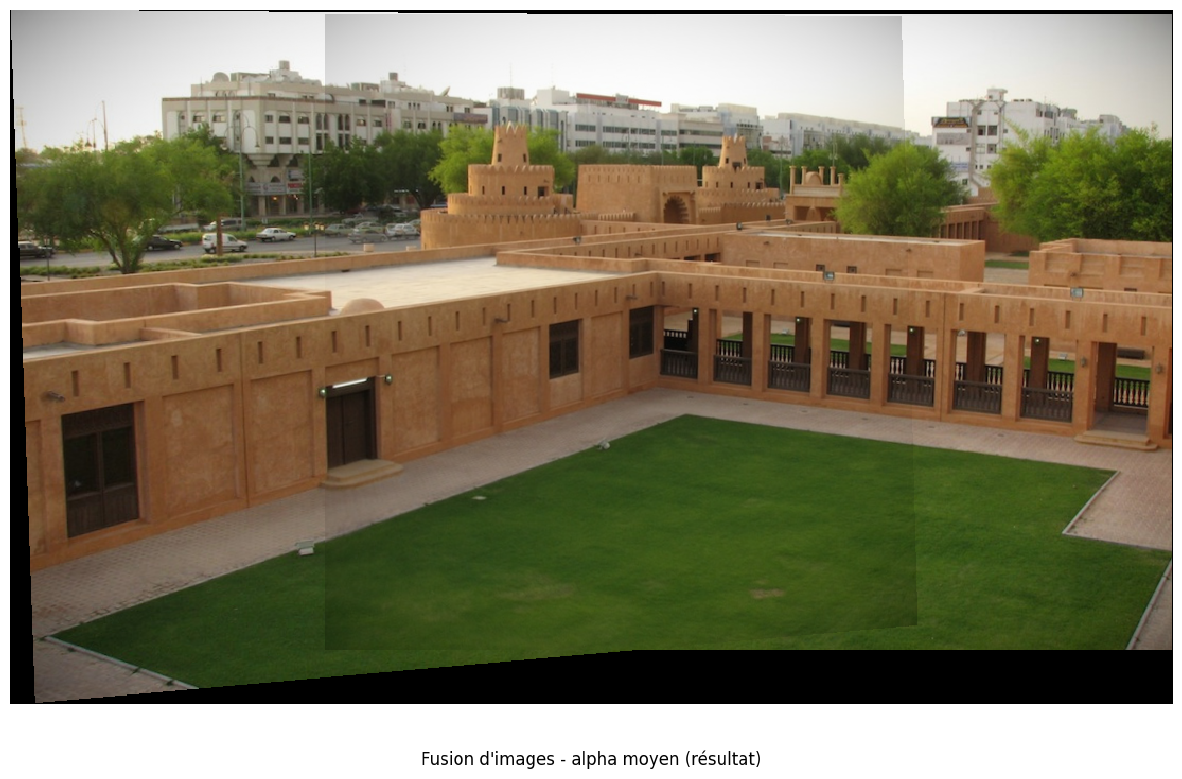

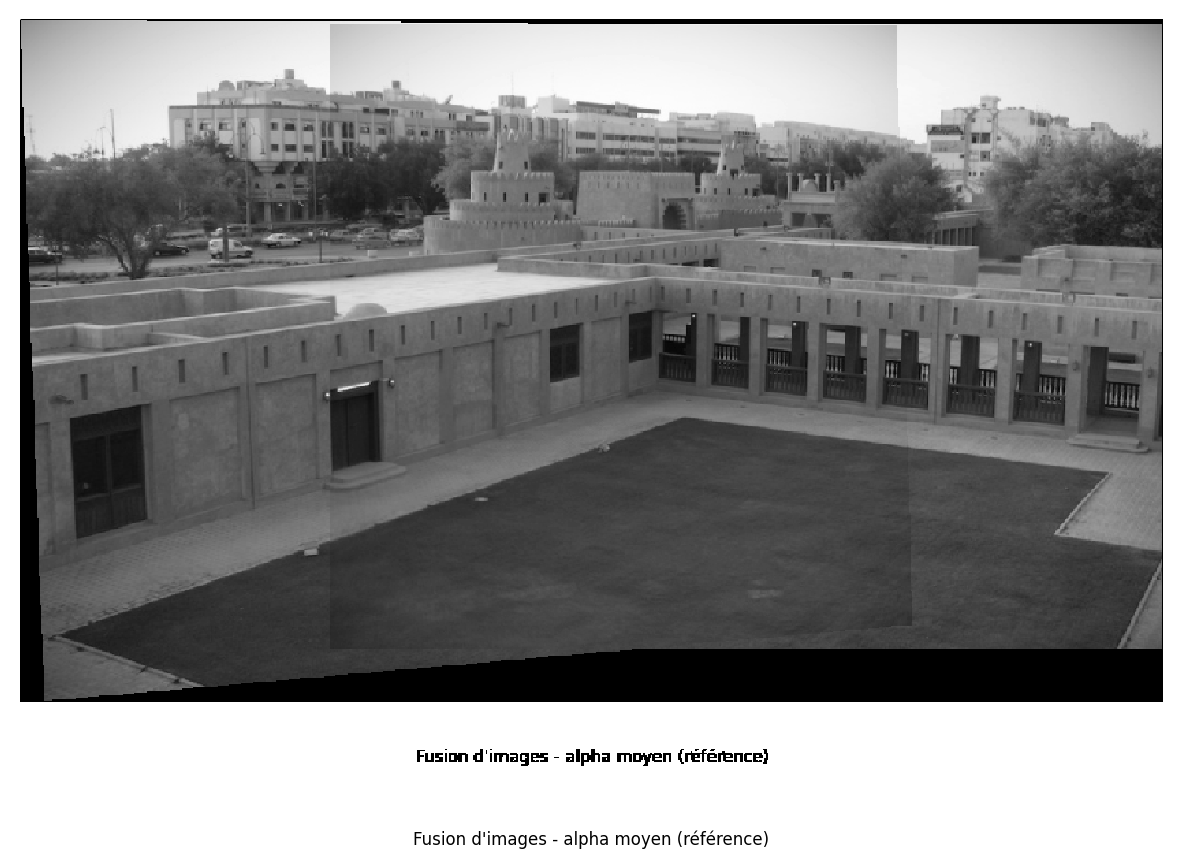

In [15]:
def naive_fusion(img1_warped, img2_warped):
    """
    fusionne deux images selon la formule :
         merged[i,j] = ( image1[i,j] + image2[i,j] ) / (alpha1[i,j]+ alpha2[i,j])

    Entrées :
        img1_warped -- Première image RGBA de dimension (Largeur, Heuteur, 4).
        img2_warped -- Deuxième image RGBA de dimension (Largeur, Heuteur, 4).

    Sorties :
        merged -- image panoramique RGB de dimension (Largeur, Heuteur, 3).
    """

    assert(img1_warped.shape[0] == img2_warped.shape[0] and img1_warped.shape[1] == img2_warped.shape[1] ), \
                 'les images doivent avoir les mêmes dimensions'

    assert(img1_warped.shape[2] == 4 and img2_warped.shape[2] == 4 ), \
                 'les images doivent avoir 4 canaux : R, G, B et A'

    merged = None

    #TODO 4 : Implémentez ici la méthode naïve de fusion de deux images en un panorama
    # TODO-BLOC-DEBUT

    rgb1 = img1_warped[:, :, :3]
    rgb2 = img2_warped[:, :, :3]

    alpha1 = img1_warped[:, :, 3]
    alpha2 = img2_warped[:, :, 3]

    alpha_sum = alpha1 + alpha2
    mask_exists = alpha_sum > 0

    merged = np.zeros_like(rgb1)

    denom = alpha_sum[:, :, np.newaxis]

    merged[mask_exists] = (rgb1[mask_exists] + rgb2[mask_exists]) / denom[mask_exists]
    # TODO-BLOC-FIN

    return merged




src1_warped = loaded['img1_warped']
src2_warped = loaded['img2_warped']

#décommentez les deux lignes suivantes pour tester la fonction naive_fusion() sur vos images (au lieu des images références).
#src1_warped = img1_warped
#src2_warped = img2_warped

merged = naive_fusion(src1_warped, src2_warped)

plt.subplots(1, 1, figsize=(15, 12))
plt.imshow(merged)
plt.axis('off')
plt.title("Fusion d'images - alpha moyen (résultat)", y=-0.10)
plt.show()

plt.subplots(1, 1, figsize=(15, 12))
plt.imshow(cv2.cvtColor(cv2.imread('merged.png'), cv2.COLOR_BGR2GRAY))
plt.axis('off')
plt.title("Fusion d'images - alpha moyen (référence)", y=-0.10)
plt.show()

### 4.5. Cartes de pondération [TODO 5] (20 points)
Vous avez sans doute remarqué les filons désagréables au milieu de votre image panoramique. Il est possible de lisser ces artefacts et produire une image plus agréable à l'oeil en utilisant une technique très simple appelée "contour progressif" (*anglais* : feathering). Actuellement, tous les pixels de la région de chevauchement des images sont pondérés de manière égale (c.-à-d. le canal alpha de l'image = 0.5). Cependant, comme les pixels aux extrémités de la zone de chevauchement sont très bien complétés par les pixels de l'autre image, nous pouvons faire en sorte qu'ils contribuent moins au signal dans le panorama final.

<img src="https://github.com/benhadid/m1vpo/blob/gh-pages/static_files/assignments/figures/feathering.png?raw=1" width="45%"/>

Le mélange par "contour progressif" peut être appliqué aux images en trois étapes :
1. Calcul d'une carte de pondération pour chaque image à fusionner : Pondération de chaque pixel de l'image source proportionnellement à sa distance du bord. Les pixels au milieu de l'image ont un poids plus important par rapport aux pixels aux bords de l'image.  
2. Application des cartes de pondérations aux images correspondantes
3. Pour chaque pixel dans l’image fusionnée finale, division de la valeur du pixel (c.-à-d. la couleur)
   par la sommes des coefficients de pondération à cet pixel.

En ce sens, réécrivez la fonction **`warp_image`** dans `panorama.py` pour qu'elle calcule, en plus de la transformation initialement implémentée, la carte de pondération des alphas de l'image transformée selon la technique du contour progressif. Le calcul des coefficients de pondération doit être contrôlé par un paramètre supplémentaire appelé `method` où :
 - method = None     -- aucun changement. La fonction retourne des images avec le canal alpha égale à 1.0 (TODO4).
 - method ='hlinear' -- calcul des coefficients de pondération de l'image transformée dans le sens horizontal seulement
 - method ='vlinear' -- calcul des coefficients de pondération de l'image transformée dans le sens vertical seulement
 - method ='linear'  -- calcul des coefficients de pondération de l'image transformée dans le sens horizontal et vertical.

Exécutez le code suivant pour visualiser les cartes de pondération obtenues à l'aide de la technique du "contour progressif".

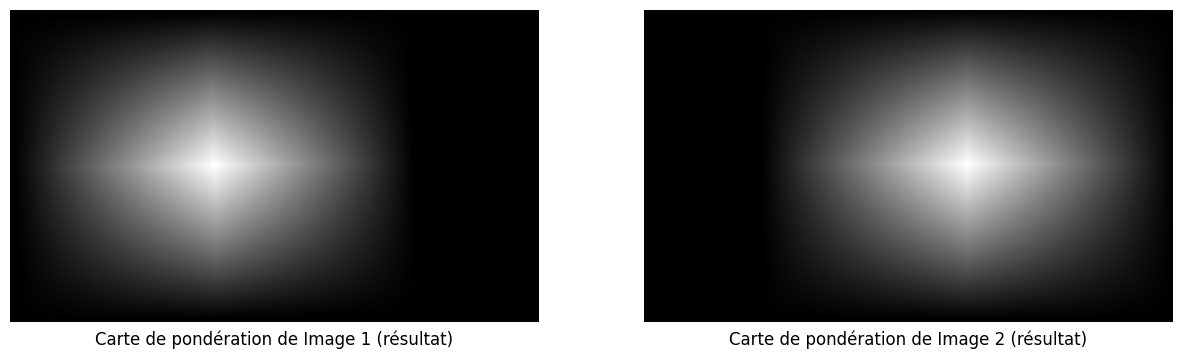

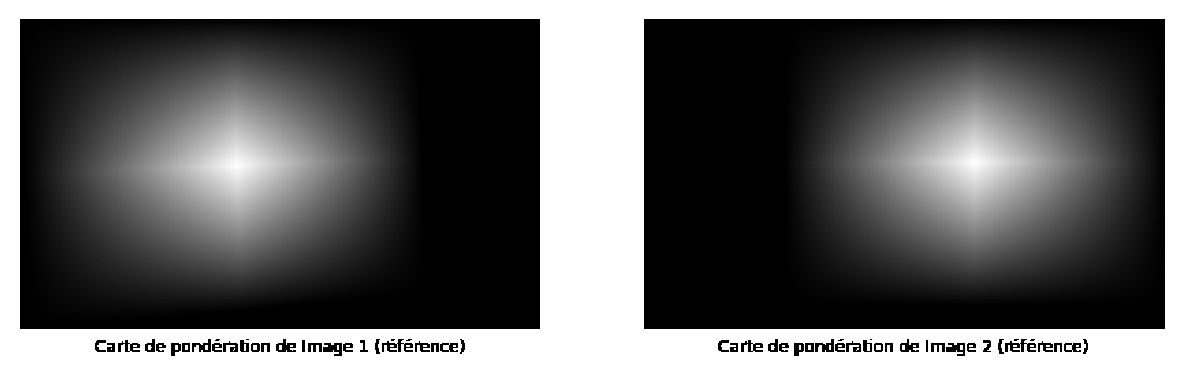

In [17]:
import numpy as np

def warp_image(img, H, output_shape, offset, method=None):
    out_w, out_h = output_shape
    img_warped = np.zeros((out_h, out_w, 3), dtype=np.float32)
    mask = np.zeros((out_h, out_w), dtype=bool)

    src = img.astype(np.float32) / 255.0
    src_h, src_w = src.shape[:2]

    # --- TODO 5: Calcul de la carte de pondération (Alpha) ---
    # Initialisation de l'alpha à 1.0 partout
    alpha_map = np.ones((src_h, src_w), dtype=np.float32)

    if method is not None:
        # Création de rampes de distance (0 au bord, 1 au centre)
        # np.linspace crée une progression linéaire
        # On utilise np.minimum pour que ça décroisse vers les deux bords

        if method in ['hlinear', 'linear']:
            h_ramp = np.linspace(0, 1, src_w)
            h_weights = np.minimum(h_ramp, h_ramp[::-1]) # Forme en pyramide/tente
            # Normalisation pour que le max soit 1.0
            h_weights /= h_weights.max()
            alpha_map *= h_weights # Broadcast sur toutes les lignes

        if method in ['vlinear', 'linear']:
            v_ramp = np.linspace(0, 1, src_h)
            v_weights = np.minimum(v_ramp, v_ramp[::-1])
            v_weights /= v_weights.max()
            alpha_map *= v_weights[:, np.newaxis] # Broadcast sur toutes les colonnes

    # --- TODO 3: Projection Inverse ---
    H_inv = np.linalg.inv(H)
    xx, yy = np.meshgrid(np.arange(out_w), np.arange(out_h))

    dst_coords = np.stack([xx.ravel() + offset[0], yy.ravel() + offset[1], np.ones(xx.size)])
    src_coords_homo = H_inv @ dst_coords

    src_x = src_coords_homo[0, :] / src_coords_homo[2, :]
    src_y = src_coords_homo[1, :] / src_coords_homo[2, :]

    valid_mask = (src_x >= 0) & (src_x < src_w - 1) & (src_y >= 0) & (src_y < src_h - 1)

    # Indices pour l'interpolation
    src_x_v = src_x[valid_mask]
    src_y_v = src_y[valid_mask]
    x0 = np.floor(src_x_v).astype(int)
    x1 = x0 + 1
    y0 = np.floor(src_y_v).astype(int)
    y1 = y0 + 1

    # Poids Bilinéaires
    wa = (x1 - src_x_v) * (y1 - src_y_v)
    wb = (x1 - src_x_v) * (src_y_v - y0)
    wc = (src_x_v - x0) * (y1 - src_y_v)
    wd = (src_x_v - x0) * (src_y_v - y0)

    # Interpolation des couleurs (RGB)
    val_rgb = (src[y0, x0] * wa.reshape(-1, 1) +
               src[y1, x0] * wb.reshape(-1, 1) +
               src[y0, x1] * wc.reshape(-1, 1) +
               src[y1, x1] * wd.reshape(-1, 1))

    # Interpolation de la carte alpha
    val_alpha = (alpha_map[y0, x0] * wa +
                 alpha_map[y1, x0] * wb +
                 alpha_map[y0, x1] * wc +
                 alpha_map[y1, x1] * wd)

    # Création du résultat final (4 canaux : R, G, B, A)
    res_rgba = np.zeros((out_h, out_w, 4), dtype=np.float32)
    res_rgba[yy.ravel()[valid_mask], xx.ravel()[valid_mask], :3] = val_rgb
    res_rgba[yy.ravel()[valid_mask], xx.ravel()[valid_mask], 3] = val_alpha

    # Masque booléen pour les pixels valides
    mask[yy.ravel()[valid_mask], xx.ravel()[valid_mask]] = True

    return res_rgba, mask


limg1_warped, m1 = warp_image(imgs[0], transforms[0], output_shape, offset, method='linear')
limg2_warped, m2 = warp_image(imgs[1], transforms[1], output_shape, offset, method='linear')

# Visualisation des cartes de pondérations
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(15, 12))
ax1.imshow(limg1_warped[:,:,3], cmap='gray')
ax1.axis('off')
ax1.set_title('Carte de pondération de Image 1 (résultat)',y=-0.10)

ax2.imshow(limg2_warped[:,:,3], cmap='gray')
ax2.axis('off')
ax2.set_title('Carte de pondération de Image 2 (résultat)',y=-0.10)
plt.show()

plt.subplots(1, 1, figsize=(15, 12))
plt.imshow(cv2.cvtColor(cv2.imread('alpha.png'), cv2.COLOR_BGR2GRAY))
plt.axis('off')
plt.show()

### 4.6. Assemblage avec pondération des images [TODO 6] (5 points)

Maintenant que nous ayons des cartes de pondération plus adaptées, nous pouvons fusioner les images transformées `img1_warped` et `img2_warped`  selon la formule suivante :

$$
dst[i,j] = \left( alpha_1\left[i,j\right] \times src_1\left[i,j\right] + alpha_2\left[i,j\right] \times src_2\left[i,j\right]\right) \bigg/ \sum_{k=1}^{2} alpha_k\left[i,j\right]
$$

Implémentez la fonction **``fusion()``** dans `panorama.py` qui réalise cette opération, puis exécutez le code ci-dessous pour validation.

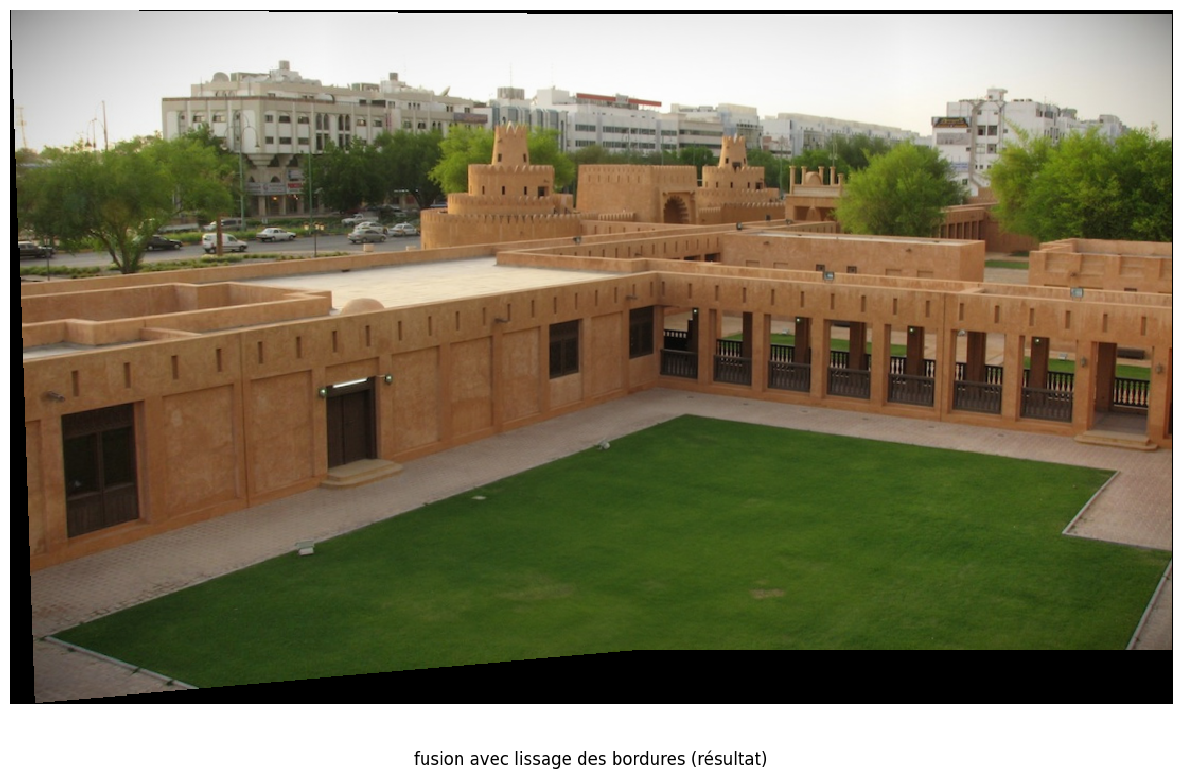

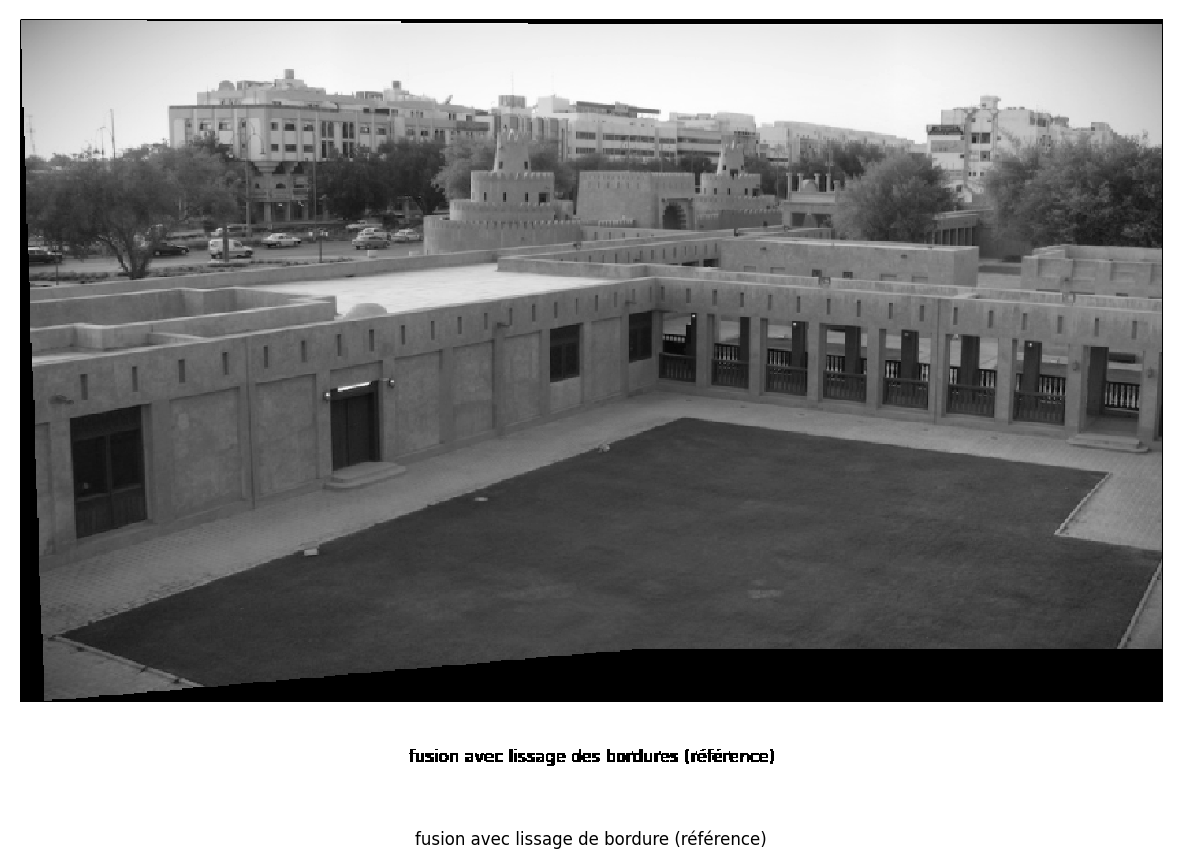

In [18]:
import numpy as np

def fusion(img1_warped, m1, img2_warped, m2):
    """
    Fusionne deux images en utilisant leurs canaux alpha comme poids.
    """

    # 1. Extraire les composantes pour l'image 1
    rgb1 = img1_warped[:, :, :3]
    alpha1 = img1_warped[:, :, 3]

    # 2. Extraire les composantes pour l'image 2
    rgb2 = img2_warped[:, :, :3]
    alpha2 = img2_warped[:, :, 3]

    # 3. Calculer le numérateur : (alpha1 * rgb1 + alpha2 * rgb2)
    # On utilise np.newaxis pour multiplier chaque canal (R, G, B) par le même alpha
    numerator = (alpha1[:, :, np.newaxis] * rgb1 +
                 alpha2[:, :, np.newaxis] * rgb2)

    # 4. Calculer le dénominateur : somme des poids (alphas)
    denominator = alpha1 + alpha2

    # 5. Gérer la fusion et éviter la division par zéro
    # On ne calcule que là où au moins un masque (m1 ou m2) est vrai
    combined_mask = m1 | m2

    # Initialiser l'image de sortie
    merged = np.zeros_like(rgb1)

    # Appliquer la division uniquement sur les pixels valides
    # On utilise np.newaxis sur le dénominateur pour l'aligner avec les 3 canaux RGB
    denom_v = denominator[combined_mask][:, np.newaxis]
    merged[combined_mask] = numerator[combined_mask] / denom_v

    return merged





src1_warped = loaded['limg1_warped']
src2_warped = loaded['limg2_warped']
lm1         = loaded['m1']
lm2         = loaded['m2']

#décommentez les quatre lignes suivantes pour tester la fonction fusion() sur vos données (au lieu des données références).
#src1_warped = limg1_warped
#src2_warped = limg2_warped
#lm1 = m1
#lm2 = m2

merged = fusion(src1_warped, lm1, src2_warped, lm2)

plt.subplots(1, 1, figsize=(15, 12))
plt.imshow(merged)
plt.axis('off')
plt.title("fusion avec lissage des bordures (résultat)", y=-0.10)
plt.show()

plt.subplots(1, 1, figsize=(15, 12))
plt.imshow(cv2.cvtColor(cv2.imread('fused.png'), cv2.COLOR_BGR2GRAY))
plt.axis('off')
plt.title("fusion avec lissage de bordure (référence)", y=-0.10)
plt.show()

### 5. Fusion d'images multiples dans un panorama [TODO  Bonus] (20 points)

Étant donné une séquence ordonnée d'images ($I_1, I_2,...,I_m,\text{ où } m \geq 2$), nous aimerions produire un panorama à partir de cette séquence. En ce sens, implémentez la fonction **`stitch_multiple_images()`** dans `panorama.py` qui réalise cette opération.


**Indications :**

- Pensez à réutiliser les fonctions que vous avez déjà implémentées dans `panorama.py`.
- Les transformations des images $I_{i}$ pour produire l'image panoramique finale doivent être référencées par rapport à l'image $I_{ref}$ &ndash; C.-à-d. le 'milieu' de votre image panoramique est indiqué par le paramètre `imgref` de la fonction `stitch_multiple_images()`.
  - Prenez chaque paire d'images voisine et calculez la matrice de transformation $\mathbf{H}_i$ qui convertit les coordonnées des pixels dans l'image $I_{i}$ aux nouvelles coordonnées dans l'image $I_{i+1}$.
  - Appliquez ensuite les opérations algébriques nécessaires pour réadapter ces transformations par rapport à l'image référence $I_{ref}$. Si vous êtes confus, vous pouvez revoir les slides du cours sur les transformations géométriques et comment les combinées pour effectuer une transformation complexe à partir d'une suite de transformations élémentaires.
  - L'inverse de la matrice de transformation $\mathbf{H}$ a l'effet inverse.

/tmp/ipykernel_24124/216848590.py:78: RuntimeWarning: invalid value encountered in divide
  res_rgba[mask, :3] = (alpha1[mask, np.newaxis] * rgb1[mask] +


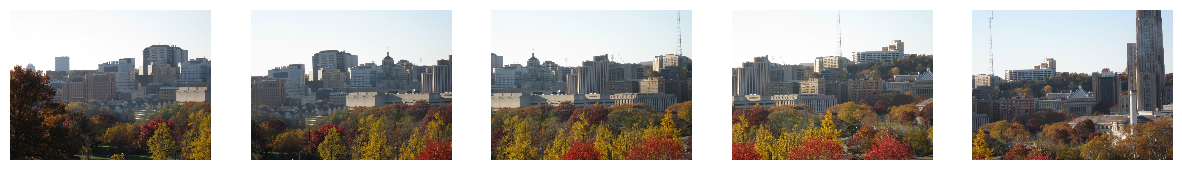

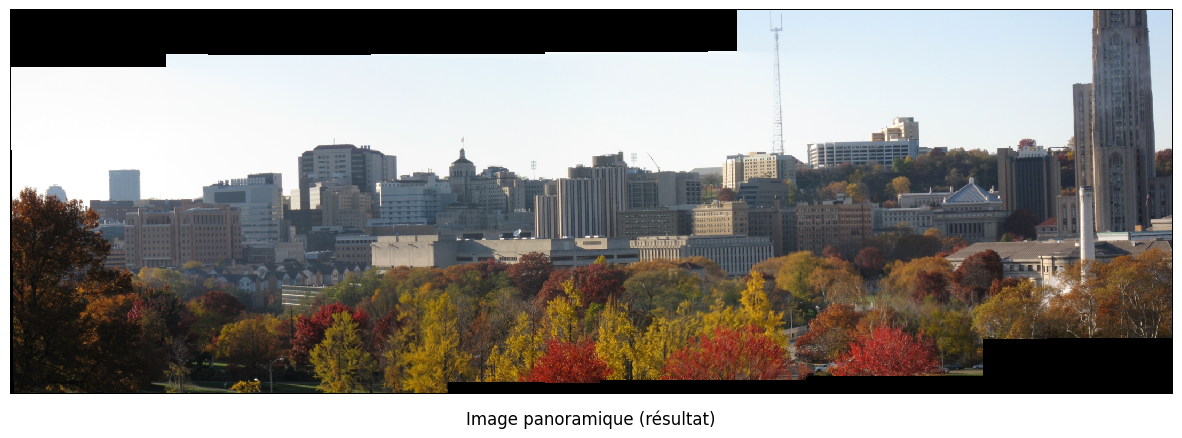

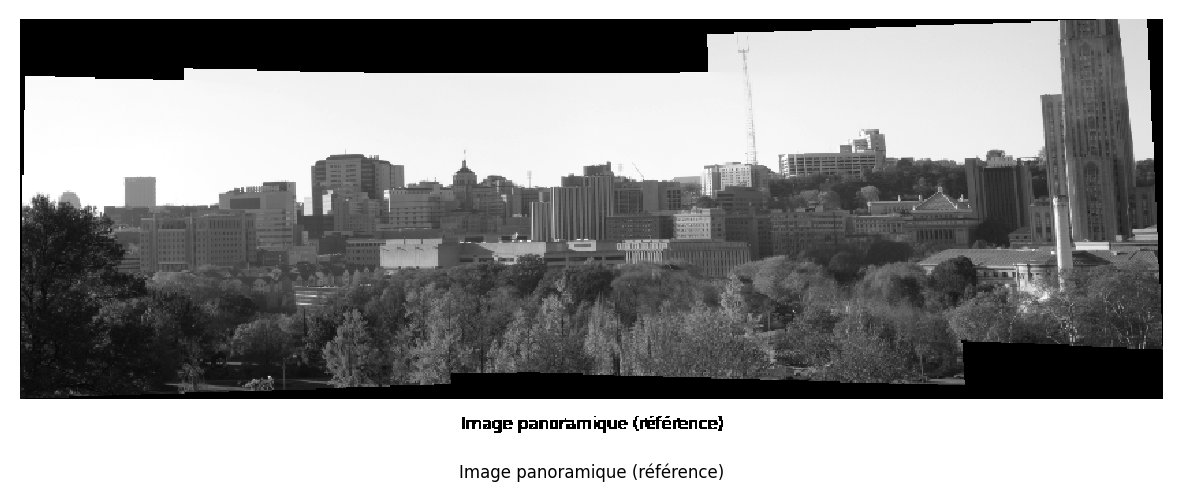

In [19]:
import numpy as np

def stitch_multiple_images(imgs_list, keypoints_list, matches_list, imgref=0, blend=None):
    n = len(imgs_list)

    # 1. Calculer les homographies entre paires adjacentes (H_i_to_i+1)
    # Il y a (n-1) homographies pour n images
    adj_H = []
    for i in range(n - 1):
        H_ij, _ = ransac(keypoints_list[i], keypoints_list[i+1], matches_list[i])
        adj_H.append(H_ij)

    # 2. Calculer les homographies globales par rapport à imgref
    # Chaque image aura une matrice M_i tel que: p_ref = M_i * p_i
    global_H = [None] * n
    global_H[imgref] = np.eye(3) # L'image de référence ne bouge pas

    # Vers la gauche de la référence (imgref-1, imgref-2...)
    for i in range(imgref - 1, -1, -1):
        # Pour aller de i vers ref: p_ref = H_{i+1->ref} * H_{i->i+1} * p_i
        global_H[i] = global_H[i+1] @ adj_H[i]

    # Vers la droite de la référence (imgref+1, imgref+2...)
    for i in range(imgref + 1, n):
        # Pour aller de i vers ref: p_ref = H_{i-1->ref} * inv(H_{i-1->i}) * p_i
        global_H[i] = global_H[i-1] @ np.linalg.inv(adj_H[i-1])

    # 3. Déterminer les dimensions du panorama final
    # On projette les 4 coins de chaque image pour trouver l'emprise totale [min_x, max_x, min_y, max_y]
    all_corners = []
    for i in range(n):
        h, w = imgs_list[i].shape[:2]
        corners = np.array([[0, 0, 1], [w, 0, 1], [w, h, 1], [0, h, 1]]).T
        projected = global_H[i] @ corners
        projected /= projected[2, :] # Normalisation homogène
        all_corners.append(projected[:2, :])

    all_corners = np.hstack(all_corners)
    min_x, min_y = np.floor(all_corners.min(axis=1)).astype(int)
    max_x, max_y = np.ceil(all_corners.max(axis=1)).astype(int)

    output_shape = (max_x - min_x, max_y - min_y)
    offset = (min_x, min_y)

    # 4. Warper toutes les images et les fusionner
    warped_images = []
    masks = []
    for i in range(n):
        img_w, m = warp_image(imgs_list[i], global_H[i], output_shape, offset, method=blend)
        warped_images.append(img_w)
        masks.append(m)

    # Fusionner successivement
    panorama_rgba = warped_images[0]
    p_mask = masks[0]

    for i in range(1, n):
        # On utilise une version étendue de fusion pour accumuler les images
        # Ici, on peut réutiliser la logique de TODO 6
        panorama_rgba = accumulate_fusion(panorama_rgba, p_mask, warped_images[i], masks[i])
        p_mask = p_mask | masks[i]

    return panorama_rgba[:, :, :3] # Retourner uniquement le RGB

def accumulate_fusion(img1_rgba, m1, img2_rgba, m2):
    # Logique identique à TODO 6 mais retourne un canal Alpha pour la prochaine itération
    alpha1 = img1_rgba[:, :, 3]
    alpha2 = img2_rgba[:, :, 3]
    rgb1 = img1_rgba[:, :, :3]
    rgb2 = img2_rgba[:, :, :3]

    sum_alpha = alpha1 + alpha2
    mask = m1 | m2

    res_rgba = np.zeros_like(img1_rgba)
    # Calcul couleur pondérée
    denom = sum_alpha[:, :, np.newaxis]
    res_rgba[mask, :3] = (alpha1[mask, np.newaxis] * rgb1[mask] +
                          alpha2[mask, np.newaxis] * rgb2[mask]) / denom[mask]
    # Accumulation alpha
    res_rgba[mask, 3] = sum_alpha[mask]
    return res_rgba






# Load images to stitch
img1 = cv2.imread('resources/city/01.jpg')
img2 = cv2.imread('resources/city/02.jpg')
img3 = cv2.imread('resources/city/03.jpg')
img4 = cv2.imread('resources/city/04.jpg')
img5 = cv2.imread('resources/city/05.jpg')

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)
img5 = cv2.cvtColor(img5, cv2.COLOR_BGR2RGB)

imgs = [img1, img2, img3, img4, img5]

keypoints_list   = []  # keypoints[i] associated with imgs[i]
descriptors_list = []  # descriptors[i] associated with keypoints[i]
for img in imgs:
    # find the keypoints and descriptors with ORB
    keypoints, descriptors = orb.detectAndCompute(img, None)
    keypoints = np.squeeze( np.array( [  kp.pt  for kp in keypoints ] ) )

    keypoints_list.append(keypoints)
    descriptors_list.append(descriptors)

# matches_list[i] décrit la paire de correspondance entre les descripteurs descriptors[i] et descriptors[i+1]
matches_list = []
for pair in zip(descriptors_list[:-1], descriptors_list[1:]):
    # find the matches between the sets of descriptors (and thus keypoints)
    matches = bf.match(pair[0], pair[1])
    matches = np.array( [ (m.queryIdx, m.trainIdx) for m in matches ] )

    matches_list.append( matches )

# Stitch images together
panorama = stitch_multiple_images(imgs, keypoints_list, matches_list, imgref=2, blend='linear')

# Plot initial images
_, ax = plt.subplots(1, len(imgs), figsize=(15, 12))
for i, img in enumerate(imgs):
    ax[i].imshow(img[:,:,:3])
    ax[i].axis('off')
plt.show()

# show panorama image
plt.subplots(1, 1, figsize=(15, 12))
plt.imshow(panorama)
plt.axis('off')
plt.title("Image panoramique (résultat)", y=-0.10)
plt.show()

plt.subplots(1, 1, figsize=(15, 12))
plt.imshow(cv2.cvtColor(cv2.imread('panorama.png'), cv2.COLOR_BGR2GRAY))
plt.axis('off')
plt.title("Image panoramique (référence)", y=-0.10)
plt.show()

<s>
## 5. Livrables

### 5.1. Le code (à remettre sur [benhadid.ddns.net](https://benhadid.ddns.net/course/M1_VPO/hw2))

Le fichier "devoir3.zip" contenant le fichier **`panorama.py`** modifié dans les zones indiquées par `#TODO-BLOC-DEBUT` et `#TODO-BLOC-FIN`.

**Le code sera remis <del>en classe pendant votre séance de TP</del> au serveur INGInious - <span style='color:Red'> aucun document ou code ne sera accepté si envoyé par mail ou clé USB</span>**.
</s>


In [ ]:
# Exécutez cette cellule puis récupérez votre fichier "devoir3.zip" depuis le panneau gauche dans Colab
# Si nécessaire, faites un 'refresh' sur le répertoire pour faire apparaître le fichier 'devoir3.zip'

!zip -r ./devoir3.zip panorama.py